In [4]:
# ========================================================
# SETUP & GPU CONFIGURATION
# ========================================================
import tensorflow as tf
import sys
from pathlib import Path

# GPU memory growth SEBELUM import modul lain
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU terdeteksi: {gpus}")
else:
    print("⚠️ GPU tidak terdeteksi, menggunakan CPU.")

# Tambahkan root ke path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

# Konstanta path
DEMO_DIR = PROJECT_ROOT / "data" / "demo_test"

print("✅ Setup selesai.")

I0000 00:00:1783933309.558844   26264 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ GPU terdeteksi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Setup selesai.


In [5]:
# ========================================================
# IMPORT FUNGSI DARI UTILS
# ========================================================
from utils.predictor import load_verify_model, run_batch_test, predict_and_display
print("✅ Modul berhasil diimpor.")

✅ Modul berhasil diimpor.


In [6]:
# ========================================================
# LOAD MODEL CLASSIFIER
# ========================================================
verify_model = load_verify_model()
print("✅ Model siap digunakan untuk inferensi.")

I0000 00:00:1783933321.399457   26264 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


✅ Model siap digunakan untuk inferensi.


In [7]:
# ========================================================
# BATCH TESTING PADA FOLDER demo_test
# ========================================================
results = run_batch_test(DEMO_DIR, verify_model, threshold=0.5)

BATCH TESTING PADA FOLDER: /home/acern/Projects/BlockchainAI/data/demo_test


I0000 00:00:1783933325.964609   26761 service.cc:153] XLA service 0x75148c06c300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783933325.964663   26761 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.3.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1783933326.007969   26761 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783933326.690879   26761 cuda_dnn.cc:461] Loaded cuDNN version 92000
E0000 00:00:1783933332.306888   26761 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1783933335.648539   26761 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


asli.jpeg                                ✅ ✅ ASLI  (confidence: 84.7%)
asli1.jpeg                               ✅ ✅ ASLI  (confidence: 97.6%)
asli2.jpeg                               ✅ ✅ ASLI  (confidence: 96.7%)
asli3.jpeg                               ✅ ✅ ASLI  (confidence: 99.8%)
asli4.jpeg                               ✅ ✅ ASLI  (confidence: 93.1%)
palsu.jpeg                               ❌ Objek tidak dikenal / bukan obat
palsu1.jpeg                              ❌ Objek tidak dikenal / bukan obat
palsu2.jpeg                              ❌ Objek tidak dikenal / bukan obat
palsu3.jpeg                              ❌ Objek tidak dikenal / bukan obat
palsu4.jpeg                              ❌ Objek tidak dikenal / bukan obat
random.jpeg                              ❌ Objek tidak dikenal / bukan obat
random1.jpeg                             ✅ ✅ ASLI  (confidence: 98.0%)
random2.jpeg                             ✅ ✅ ASLI  (confidence: 97.7%)
random3.jpeg                             ❌ Obje

/home/acern/Projects/BlockchainAI/.venv-training/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


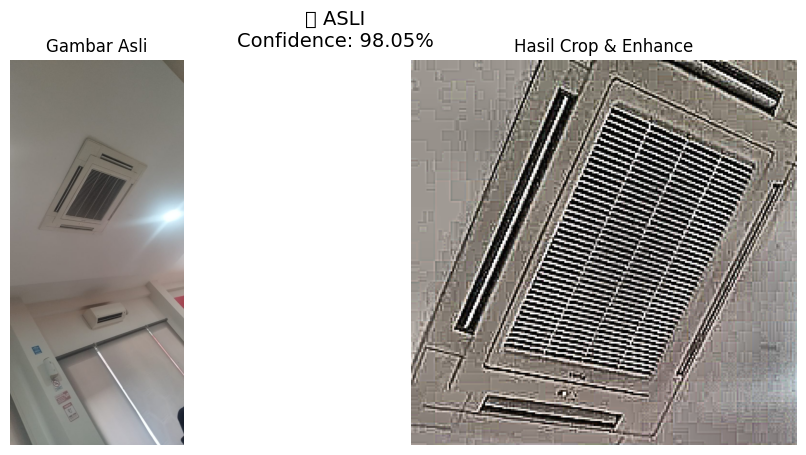

File    : random1.jpeg
Status  : TERVERIFIKASI
Hasil   : ✅ ASLI
Confidence: 98.05%


('TERVERIFIKASI', '✅ ASLI', 0.9804813582450151)

In [10]:
# ========================================================
# VISUALISASI CONTOH (opsional)
# ========================================================
# Ganti dengan nama file yang ada di demo_test
predict_and_display(str(DEMO_DIR / 'random1.jpeg'), verify_model)